In [140]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dense, Flatten
%matplotlib inline
import numpy as np

In [141]:
(X_train, y_train), (X_test, y_test)=keras.datasets.mnist.load_data()

In [142]:
len(X_train)

60000

In [143]:
len(X_test)

10000

In [144]:
X_train[0].shape

(28, 28)

In [145]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

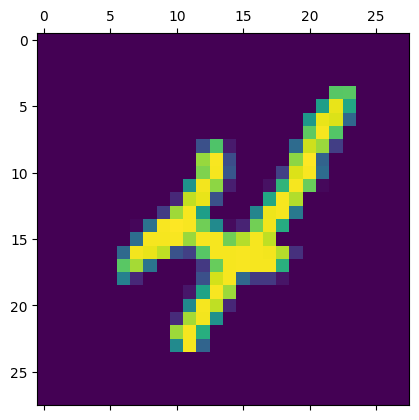

In [146]:
plt.matshow(X_train[9])

In [147]:
y_train[9]

np.uint8(4)

In [148]:
X_train = X_train/255
X_test = X_test/255

In [149]:
# converting 2d array into 1 dimension
X_train_flattened = X_train.reshape(len(X_train), 28*28)
X_test_flattened = X_test.reshape(len(X_test), 28*28)

In [150]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [154]:
X_train_flattened.shape

(60000, 784)

In [ ]:
# now we create a simple neural network
model = keras.Sequential([
    Dense(784),
    Dense(10, activation="softmax")
])
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

#model actually trains here
model.fit(X_train_flattened, y_train, epochs=5)

/home/mukundaparajuli/Desktop/machinelearning/deeplearning/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 784), dtype=float32) with name 'keras_tensor_32' and path ''. Expected shape (None, 28, 28), but input has incompatible shape (32, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 784), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
model.evaluate(X_test_flattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9148 - loss: 0.3023


[0.302297443151474, 0.9147999882698059]

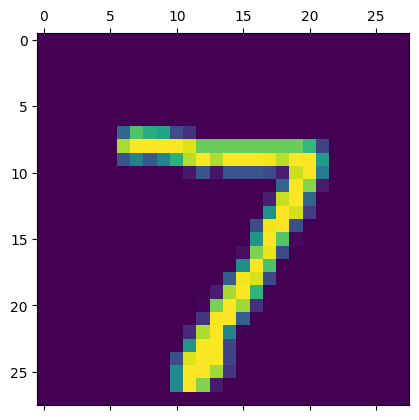

In [ ]:
plt.matshow(X_test[0])

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([8.0487692e-01, 6.7966187e-07, 7.4776733e-01, 9.9962467e-01,
       1.5635002e-01, 8.0570310e-01, 3.2110493e-06, 9.9999875e-01,
       7.3895609e-01, 9.9837357e-01], dtype=float32)

In [ ]:
np.argmax(y_predicted[0])

np.int64(7)

In [ ]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]

In [ ]:
cm = tf.math.confusion_matrix(labels=y_test, predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 927,    0,    2,    4,    3,   14,   17,    6,    4,    3],
       [   0, 1098,   14,    3,    1,    2,    4,    2,   11,    0],
       [   5,    4,  958,    9,    7,    5,   10,    9,   20,    5],
       [   0,    0,   33,  912,    2,   32,    2,   10,    7,   12],
       [   1,    1,   11,    0,  911,    0,    5,    4,    3,   46],
       [   7,    1,    7,   32,    9,  782,   12,    9,   22,   11],
       [   7,    2,   17,    1,   11,   20,  896,    2,    1,    1],
       [   0,    5,   31,    6,    7,    1,    0,  933,    0,   45],
       [   3,    5,   13,   50,    9,   50,   11,   10,  793,   30],
       [   3,    3,    1,   14,   25,    6,    0,   17,    3,  937]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Test')

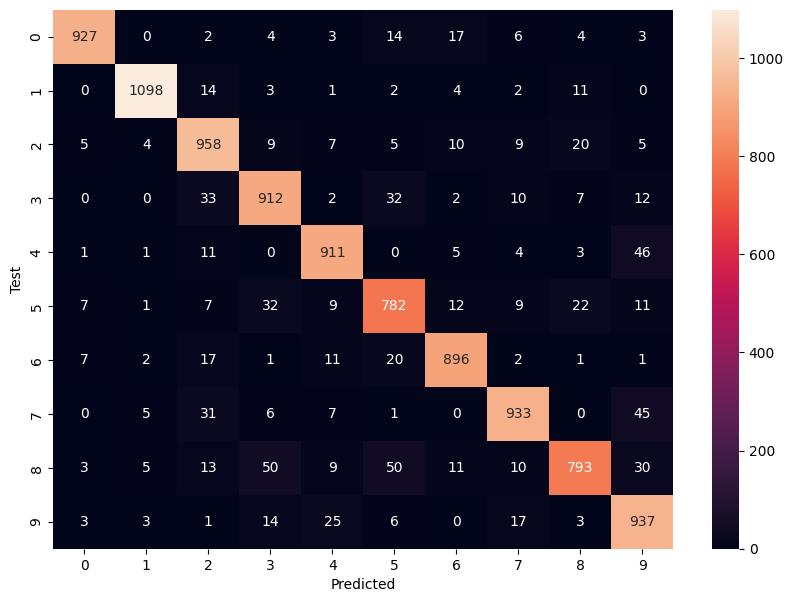

In [ ]:
import seaborn as sn
plt.figure(figsize=(10, 7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Test")

In [ ]:
model = keras.Sequential([
     Flatten(input_shape=(28,28)),
    Dense(100, activation="relu"),
    Dense(10, activation="sigmoid")
])
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened, y_train, epochs=5)

/home/mukundaparajuli/Desktop/machinelearning/deeplearning/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 784), dtype=float32) with name 'keras_tensor_22' and path ''. Expected shape (None, 28, 28), but input has incompatible shape (32, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 784), dtype=float32)
  • training=True
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
model.evaluate(X_test_flattened, y_test)